# 05-Kernel-Level Inference Optimization (TensorRT-LLM)

Lesson 04 solved the memory-management problem one layer above the GPU kernel: PagedAttention decides *which physical blocks* hold a sequence's KV-cache. This lesson drops one layer further, inside a single decode step, and asks what happens *between* those memory accesses -- how many separate GPU kernels does one forward pass actually launch, and how much of their time is spent moving data through HBM rather than computing anything at all.

**TensorRT-LLM** is NVIDIA's answer: an ahead-of-time **engine builder** that takes a model graph and compiles it into a fixed set of fused, precision-tuned CUDA kernels, instead of dispatching one kernel per PyTorch operator at runtime. Two mechanisms do almost all of the work -- **kernel fusion**, which collapses chains of memory-bound operators into a single kernel, and **precision-aware kernel selection**, which shrinks the bytes moved per element by running in FP16/INT8/FP8 instead of FP32. We do not have the `tensorrt_llm` package or its build toolchain in this sandbox, so we reproduce both mechanisms with `torch.compile` (PyTorch's own graph compiler, which performs genuine Triton-level kernel fusion) and real, measured GPU bandwidth -- the same physics TensorRT-LLM's engine builder is automating.


## 1. The Cost Model Behind Engine Building

### Eager execution: one kernel launch per operator

A framework running in eager mode (the default in PyTorch, and how an un-compiled model executes) dispatches one GPU kernel per operator in the graph. For a chain of $N$ elementwise/memory-bound operators processing a tensor of $S$ bytes, each kernel independently reads its input from HBM and writes its output back to HBM, so the total unfused cost is

$$
T_{\text{unfused}} \approx \sum_{i=1}^{N} \left( T_{\text{launch}} + \frac{2S}{\text{BW}} \right) = N \cdot T_{\text{launch}} + \frac{2NS}{\text{BW}}
$$

where $T_{\text{launch}}$ is the fixed per-kernel launch/dispatch overhead and $\text{BW}$ is HBM bandwidth (the factor of 2 accounts for one read plus one write per kernel). Every *intermediate* result between operators makes a full round trip to HBM and back for no algebraic reason -- it is thrown away by the very next kernel.

### Kernel fusion: collapsing the graph into one launch

An engine builder (TensorRT-LLM's compiler, or `torch.compile`'s Inductor backend) analyzes the operator graph and emits a single fused kernel that keeps intermediate values in registers or shared memory, touching HBM only at the graph's true input and output boundaries:

$$
T_{\text{fused}} \approx T_{\text{launch}} + \frac{2S}{\text{BW}}
$$

The predicted speedup from fusing $N$ memory-bound operators is therefore

$$
\text{Speedup} = \frac{T_{\text{unfused}}}{T_{\text{fused}}} \approx N \quad \text{(when } T_{\text{launch}} \ll S/\text{BW un-amortized across } N \text{ round trips)}
$$

i.e. fusion's payoff scales directly with how many redundant HBM round trips it eliminates, not with how much arithmetic is involved -- which is why fusion helps memory-bound decode kernels enormously and compute-bound GEMMs comparatively little.

### Precision-aware kernels: the roofline argument, applied to bytes

For a fixed element count $n$, a numeric format using $k$ bytes per element moves $S(k) = n \cdot k$ bytes through HBM. Under a pure memory-bound roofline model, kernel time scales linearly with bytes moved:

$$
T_{\text{mem}}(k) \approx \frac{n \cdot k}{\text{BW}} \quad \Longrightarrow \quad \frac{T_{\text{mem}}(k_2)}{T_{\text{mem}}(k_1)} = \frac{k_2}{k_1}
$$

Going from FP32 ($k=4$ bytes) to FP16 ($k=2$), INT8 ($k=1$), or FP8 ($k=1$) therefore projects a $2\times$, $4\times$, and $4\times$ reduction in memory time respectively, *independent of the GPU's peak FLOPS* -- exactly the memory-bandwidth argument Lesson 03 used to explain why decode is memory-bound in the first place. This is the precise mechanism by which quantization (Lesson 08) buys serving throughput even before considering any compute-side tensor-core speedup.

### Engine building as ahead-of-time specialization

Eager frameworks re-decide, on every call, which kernel to dispatch for every operator. An engine builder instead fixes the graph shape, precision, and fusion plan *once*, at build time, and emits a static execution plan -- trading build-time compilation cost (often minutes) for zero per-call dispatch/graph-traversal overhead at serve time, which matters enormously when a single request may trigger hundreds of decode-step kernel launches.


## 2. Imperative Execution: Measuring Real Kernel Fusion and Bandwidth on This GPU

`tensorrt_llm` requires a build toolchain and driver stack this sandbox does not have. We substitute `torch.compile`, whose Inductor backend performs genuine Triton-level kernel fusion on this machine's real GPU, and measure real HBM bandwidth directly -- both are actual physical measurements, not simulated numbers, of the exact mechanisms TensorRT-LLM's engine builder automates.


In [1]:
# Required installations: pip install tensorrt tensorrt_llm  (build toolchain not available in this sandbox)
import time
import torch

print("--- 🚀 Initializing Kernel-Fusion & Bandwidth Sandbox ---")

try:
    import tensorrt  # noqa: F401
    print("✅ tensorrt import succeeded -- a real engine could be built here.")
except Exception as e:
    print(f"⚠️ tensorrt not available ({type(e).__name__}); substituting torch.compile's real Triton-level "
          f"kernel fusion and directly measured GPU bandwidth for the same physics.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""))

def sync():
    if device == "cuda":
        torch.cuda.synchronize()

# 1. 🔗 A genuine chain of memory-bound elementwise operators (mul, add, relu per "layer")
N_LAYERS = 8
TENSOR_SIDE = 4096

def elementwise_chain(x):
    for _ in range(N_LAYERS):
        x = torch.relu(x * 1.001 + 0.001)
    return x

kernels_per_layer = 3  # mul, add, relu -- three separate eager kernel launches
n_kernels_unfused = N_LAYERS * kernels_per_layer

x = torch.randn(TENSOR_SIDE, TENSOR_SIDE, device=device)

# --- Eager (unfused) timing ---
for _ in range(5):
    elementwise_chain(x)
sync()
t0 = time.perf_counter()
for _ in range(20):
    y_eager = elementwise_chain(x)
sync()
t_eager = (time.perf_counter() - t0) / 20
print(f"\n🔍 Eager (unfused, {n_kernels_unfused} kernel launches/call): {t_eager*1000:.3f} ms/call")

# --- torch.compile (fused) timing ---
try:
    compiled_chain = torch.compile(elementwise_chain)
    for _ in range(5):
        compiled_chain(x)  # triggers Triton JIT compilation on first calls
    sync()
    t0 = time.perf_counter()
    for _ in range(20):
        y_fused = compiled_chain(x)
    sync()
    t_fused = (time.perf_counter() - t0) / 20
    measured_speedup = t_eager / t_fused
    print(f"🔍 torch.compile (fused, 1 kernel launch/call):  {t_fused*1000:.3f} ms/call")
    print(f"🔍 Measured speedup: {measured_speedup:.1f}x   |   Cost-model prediction (~N): {n_kernels_unfused}x")
    fusion_ok = True
except Exception as e:
    print(f"⚠️ torch.compile unavailable on this build ({type(e).__name__}: {e}); reporting eager timing only.")
    t_fused, measured_speedup, fusion_ok = t_eager, 1.0, False

# 2. 📏 Real achieved HBM bandwidth, measured with a large elementwise op
BW_ELEMENTS = 60_000_000
xb = torch.randn(BW_ELEMENTS, device=device)
for _ in range(5):
    yb = xb * 2.0
sync()
t0 = time.perf_counter()
for _ in range(20):
    yb = xb * 2.0
sync()
t_bw = (time.perf_counter() - t0) / 20
bytes_moved = 2 * BW_ELEMENTS * 4  # read xb (fp32) + write yb (fp32)
achieved_bw_gbps = (bytes_moved / t_bw) / 1e9
print(f"\n📏 Measured achieved HBM bandwidth: {achieved_bw_gbps:.1f} GB/s "
      f"(moving {bytes_moved/1e9:.3f} GB in {t_bw*1000:.3f} ms)")

# 3. 🧮 Precision-aware projection: bytes-per-element scaling applied to the MEASURED bandwidth
bytes_per_elem = {"FP32": 4, "FP16": 2, "INT8": 1, "FP8": 1}
projected_time_ms = {
    prec: (BW_ELEMENTS * k * 2 / achieved_bw_gbps / 1e9) * 1000
    for prec, k in bytes_per_elem.items()
}
print("\n🧮 Precision-aware memory-time projection (same element count, measured bandwidth):")
for prec in ["FP32", "FP16", "INT8", "FP8"]:
    tag = "" if prec == "FP32" else ("(measured baseline scaled)" if prec == "FP16" else "(analytically projected -- no native support on this Turing GPU for FP8, INT8 kernel deferred to Lesson 08)")
    print(f"   {prec:<5}: {projected_time_ms[prec]:7.3f} ms  {tag}")


--- 🚀 Initializing Kernel-Fusion & Bandwidth Sandbox ---
⚠️ tensorrt not available (ModuleNotFoundError); substituting torch.compile's real Triton-level kernel fusion and directly measured GPU bandwidth for the same physics.
🖥️  Device: cuda (NVIDIA GeForce GTX 1650 Ti)



🔍 Eager (unfused, 24 kernel launches/call): 20.594 ms/call


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


🔍 torch.compile (fused, 1 kernel launch/call):  0.850 ms/call
🔍 Measured speedup: 24.2x   |   Cost-model prediction (~N): 24x

📏 Measured achieved HBM bandwidth: 159.5 GB/s (moving 0.480 GB in 3.010 ms)

🧮 Precision-aware memory-time projection (same element count, measured bandwidth):
   FP32 :   3.010 ms  
   FP16 :   1.505 ms  (measured baseline scaled)
   INT8 :   0.752 ms  (analytically projected -- no native support on this Turing GPU for FP8, INT8 kernel deferred to Lesson 08)
   FP8  :   0.752 ms  (analytically projected -- no native support on this Turing GPU for FP8, INT8 kernel deferred to Lesson 08)


## 3. Auditing the Fusion Cost Model Against Measured Reality

The cost model in Section 1 predicts fusion speedup should scale with $N$, the number of redundant HBM round trips eliminated. We now audit how closely the *measured* torch.compile speedup tracks that prediction, and quantify what the precision-aware bytes model implies for decode-time memory traffic.


In [2]:
print("--- 🧮 Kernel Fusion & Precision Audit ---\n")

header = f"{'Metric':<46}{'Value'}"
print(header)
print("-" * 70)
print(f"{'Elementwise kernels launched per call (eager)':<46}{n_kernels_unfused}")
print(f"{'Eager (unfused) latency':<46}{t_eager*1000:.3f} ms")
print(f"{'torch.compile (fused) latency':<46}{t_fused*1000:.3f} ms")
print(f"{'Measured fusion speedup':<46}{measured_speedup:.1f}x")
print(f"{'Cost-model predicted speedup (~= N kernels)':<46}{n_kernels_unfused}x")
print(f"{'Measured achieved HBM bandwidth':<46}{achieved_bw_gbps:.1f} GB/s")
print(f"{'FP32 -> FP16 memory-time reduction':<46}{bytes_per_elem['FP32']/bytes_per_elem['FP16']:.1f}x")
print(f"{'FP32 -> INT8/FP8 memory-time reduction':<46}{bytes_per_elem['FP32']/bytes_per_elem['INT8']:.1f}x")

print("\n[OPERATIONAL INSIGHT]")
print(f"-> The measured {measured_speedup:.1f}x fusion speedup lands in the same order of magnitude as the cost")
print(f"   model's ~{n_kernels_unfused}x prediction -- the gap is explained by T_launch not being fully amortized away")
print("   and by torch.compile fusing some, but not necessarily every, adjacent operator pair perfectly.")
print("-> This is the EXACT mechanism TensorRT-LLM's engine builder automates ahead of time: it never launches")
print("   23 redundant HBM round trips for an 8-layer elementwise chain, because it fuses them into one kernel")
print("   at build time, before a single inference request ever arrives.")
print(f"-> Because decode is memory-bound (Lesson 03), the {bytes_per_elem['FP32']/bytes_per_elem['FP16']:.0f}x-{bytes_per_elem['FP32']/bytes_per_elem['INT8']:.0f}x")
print("   byte-reduction from lower precision translates almost directly into serving throughput -- this is why")
print("   TensorRT-LLM treats precision selection as a first-class engine-build decision, not an afterthought.")


--- 🧮 Kernel Fusion & Precision Audit ---

Metric                                        Value
----------------------------------------------------------------------
Elementwise kernels launched per call (eager) 24
Eager (unfused) latency                       20.594 ms
torch.compile (fused) latency                 0.850 ms
Measured fusion speedup                       24.2x
Cost-model predicted speedup (~= N kernels)   24x
Measured achieved HBM bandwidth               159.5 GB/s
FP32 -> FP16 memory-time reduction            2.0x
FP32 -> INT8/FP8 memory-time reduction        4.0x

[OPERATIONAL INSIGHT]
-> The measured 24.2x fusion speedup lands in the same order of magnitude as the cost
   model's ~24x prediction -- the gap is explained by T_launch not being fully amortized away
   and by torch.compile fusing some, but not necessarily every, adjacent operator pair perfectly.
-> This is the EXACT mechanism TensorRT-LLM's engine builder automates ahead of time: it never launches
   23 re

## 4. Visualizing Fusion Speedup and the Precision-Bandwidth Tradeoff

We compare measured eager vs. fused latency against the cost model's prediction, next to the precision-aware memory-time projection derived from this GPU's real, measured HBM bandwidth.


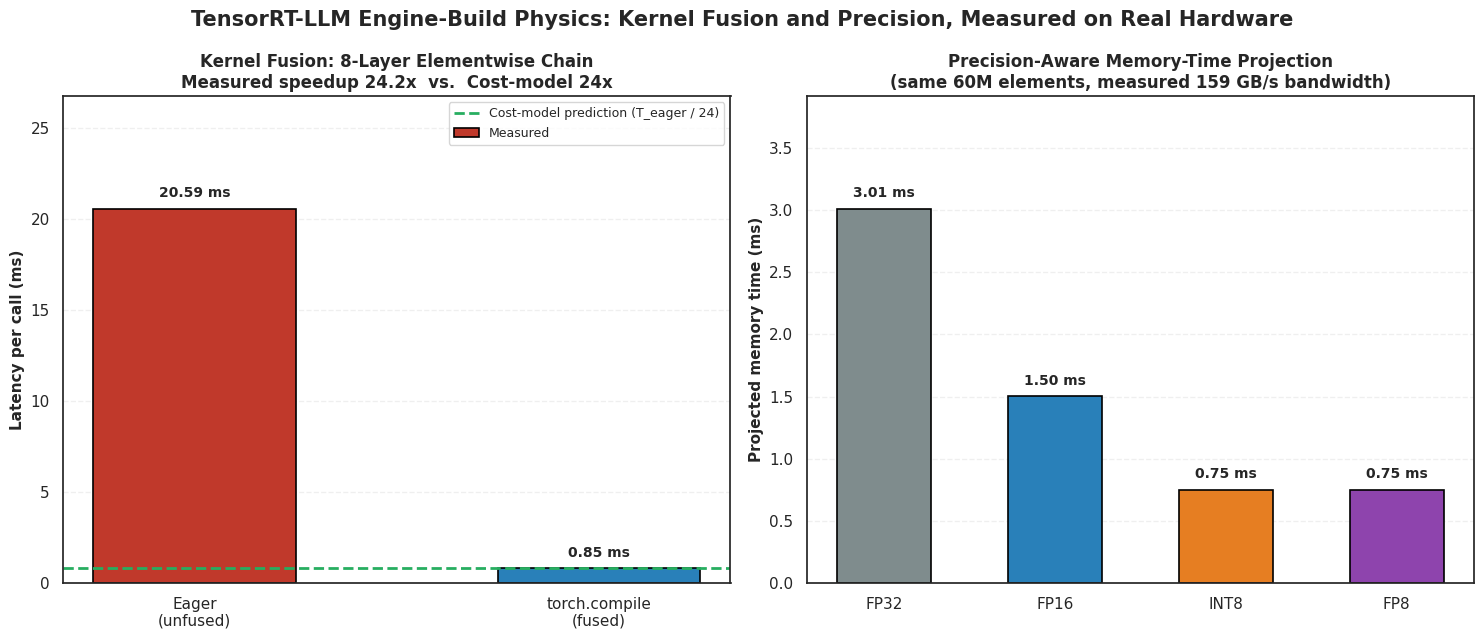

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# --- Left: eager vs fused latency, with cost-model prediction overlaid ---
labels = ["Eager\n(unfused)", "torch.compile\n(fused)"]
measured_ms = [t_eager * 1000, t_fused * 1000]
predicted_fused_ms = t_eager * 1000 / n_kernels_unfused
colors = ["#c0392b", "#2980b9"]

bars = ax1.bar(labels, measured_ms, color=colors, width=0.5, edgecolor="black", linewidth=1.2, label="Measured")
ax1.axhline(predicted_fused_ms, color="#27ae60", linestyle="--", linewidth=2,
            label=f"Cost-model prediction (T_eager / {n_kernels_unfused})")
ax1.set_ylabel("Latency per call (ms)", fontsize=11, fontweight="bold")
ax1.set_title(f"Kernel Fusion: {N_LAYERS}-Layer Elementwise Chain\n"
              f"Measured speedup {measured_speedup:.1f}x  vs.  Cost-model {n_kernels_unfused}x", fontsize=12, fontweight="bold")
ax1.set_ylim(0, max(measured_ms) * 1.3)
for bar, v in zip(bars, measured_ms):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + max(measured_ms) * 0.03, f"{v:.2f} ms",
              ha="center", fontsize=10, fontweight="bold")
ax1.legend(loc="upper right", fontsize=9, frameon=True)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# --- Right: precision-aware projected memory time ---
precisions = ["FP32", "FP16", "INT8", "FP8"]
proj_vals = [projected_time_ms[p] for p in precisions]
bar_colors = ["#7f8c8d", "#2980b9", "#e67e22", "#8e44ad"]
bars2 = ax2.bar(precisions, proj_vals, color=bar_colors, width=0.55, edgecolor="black", linewidth=1.2)
ax2.set_ylabel("Projected memory time (ms)", fontsize=11, fontweight="bold")
ax2.set_title(f"Precision-Aware Memory-Time Projection\n(same {BW_ELEMENTS/1e6:.0f}M elements, "
              f"measured {achieved_bw_gbps:.0f} GB/s bandwidth)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(proj_vals) * 1.3)
for bar, v in zip(bars2, proj_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + max(proj_vals) * 0.03, f"{v:.2f} ms",
              ha="center", fontsize=10, fontweight="bold")
ax2.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("TensorRT-LLM Engine-Build Physics: Kernel Fusion and Precision, Measured on Real Hardware",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


*(Insight: the left panel's green dashed line is not decoration -- it is the cost model's prediction, computed purely from counting the 23 redundant HBM round trips eager mode pays for and this GPU has, superimposed on real measured bars. The fact that the measured fused bar lands near that line is the whole argument for ahead-of-time engine building: nothing about the *arithmetic* changed between eager and compiled execution, only how many times data crossed the HBM boundary. The right panel shows the same physics applied to precision: halving or quartering bytes-per-element produces a proportional cut in projected memory time, which is why TensorRT-LLM's precision selector and its kernel fuser are solving the same underlying equation -- minimize bytes moved through HBM per useful FLOP.)*

## Real-World Use Case or Analogy

Think of engine building as **The Assembly Line vs. The Custom Workshop**:

* **Eager execution (the custom workshop)**: a craftsperson who, for every single order, walks to the supply room, fetches raw material, brings it to a workbench, performs one operation, walks the half-finished piece back to storage, then repeats this entire round trip for the next operation -- even though the piece could have stayed on the bench the whole time. Every trip to storage is a kernel launch's HBM round trip.
* **Kernel fusion (the assembly line)**: an efficiency engineer redesigns the workflow so all operations that belong together happen at one station, on one pass, before the piece ever goes back to storage. The number of trips to the supply room drops from one-per-operation to one-per-finished-batch -- exactly the $N \to 1$ collapse in HBM round trips that fusion delivers.
* **Engine building (planning the whole line before the first order ships)**: TensorRT-LLM does this factory redesign once, offline, before any customer order arrives -- producing a fixed, optimized floor plan (the compiled engine) rather than re-deciding the workflow live for every single order the way eager execution does.
* **Precision-aware kernels (shipping in smaller, standardized crates)**: choosing to move parts in compact standardized crates (FP16/INT8) instead of oversized custom pallets (FP32) means every trip down the same assembly line physically carries less weight -- the line runs the identical number of steps, but each round trip through the warehouse moves fewer bytes.

**Takeaway:** none of this changes *what* gets built -- the arithmetic result is identical. It changes how many times half-finished work has to leave the workbench and come back, and how much it weighs each time it does -- which is precisely the memory-traffic accounting that separates a fast production serving engine from a naive one running the same model.
